In [39]:
import globals as gl

import os
import numpy as np
import sys

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append('/Users/mnlmrc/Documents/GitHub')
sys.path.append('/Users/mnlmrc/Documents/GitHub/Functional_Fusion')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub/Functional_Fusion')

import rsatoolbox as rsa


plt.close('all')
plt.style.use('default')


# Reliability (planning) #

Text(0, 0.5, 'Correlation')

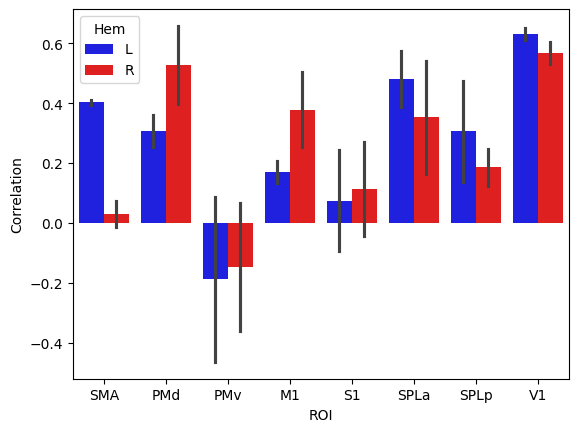

In [41]:
snS = [102, 103, 104]
experiment = 'smp2'
glm = 12

Y = list()
cond_vec = list()

corr = {
    'Hem': [],
    'ROI': [],
    'corr': [],
    'participant_id': []
}

for Hem in ['L', 'R']:
    for roi in gl.rois['ROI']:
        
        dist = list()
        for sn in snS:
            
            rdms = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
            rdms = rdms.subset_pattern(by='conds', value=['0%', '25%', '50%', '75%', '100%'])
            dist_tmp = rdms.get_matrices()[0]
            n = dist_tmp.shape[0]
            idx = np.triu_indices(n, k=1)
            dist.append(dist_tmp[idx])
        
        dist = np.stack(dist)
        
        for i, sn in enumerate(snS):
            dist1 = dist[i]
            dist2 = np.delete(dist, i, axis=0).mean(axis=0)
            
            corr_tmp = np.corrcoef(dist1, dist2)[0, 1]
        
            corr['ROI'].append(roi)
            corr['Hem'].append(Hem)
            corr['corr'].append(corr_tmp)
            corr['participant_id'].append(f'subj{sn}')

fig, axs = plt.subplots()
sns.barplot(ax=axs, data=corr, y='corr', x='ROI', hue='Hem', errorbar='se', palette={'L': 'blue', 'R': 'red'},)
            
axs.set_ylabel('Correlation')


Text(0, 0.5, 'Correlation')

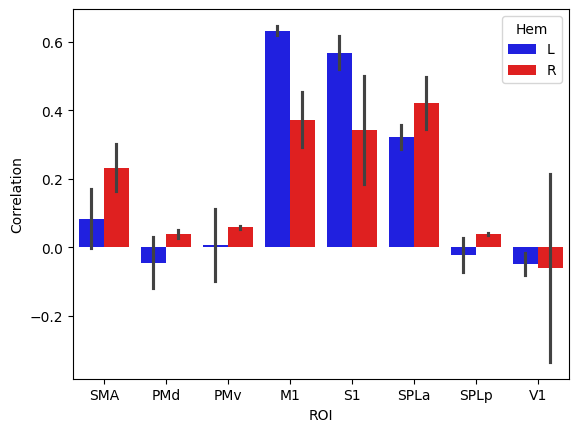

In [46]:
snS = [102, 103, 104]
experiment = 'smp2'
glm = 12

Y = list()
cond_vec = list()

corr = {
    'Hem': [],
    'ROI': [],
    'corr': [],
    'participant_id': []
}

for Hem in ['L', 'R']:
    for roi in gl.rois['ROI']:
        
        dist = list()
        for sn in snS:
            
            rdms = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
            rdms = rdms.subset_pattern(by='conds', value=['25%,index', '50%,index', '75%,index', '100%,index', '0%,ring', '25%,ring', '50%,ring', '75%,ring'])
            dist_tmp = rdms.get_matrices()[0]
            n = dist_tmp.shape[0]
            idx = np.triu_indices(n, k=1)
            dist.append(dist_tmp[idx])
        
        dist = np.stack(dist)
        
        for i, sn in enumerate(snS):
            dist1 = dist[i]
            dist2 = np.delete(dist, i, axis=0).mean(axis=0)
            
            corr_tmp = np.corrcoef(dist1, dist2)[0, 1]
        
            corr['ROI'].append(roi)
            corr['Hem'].append(Hem)
            corr['corr'].append(corr_tmp)
            corr['participant_id'].append(f'subj{sn}')

fig, axs = plt.subplots()
sns.barplot(ax=axs, data=corr, y='corr', x='ROI', hue='Hem', errorbar='se', palette={'L': 'blue', 'R': 'red'},)
            
axs.set_ylabel('Correlation')